### Our group consists of 5 members:
1. ##### CCDS NGUYEN THANH DUY
2. ##### CCDS AGALYAA GOPALAKRISHNAN
3. ##### CCDS LUM YU PEI
4. ##### CCDS SARIN LAKSHYA ANUJ
5. ##### CCDS THANG JING MIN

### Algorithm design
This is the problem about combinatorial optimization.
Our group apply Heuristic Methods, which find good solutions in a reasonable time without guaranteeing optimality.

#### Greedy Algorithm
##### Description:
Create a step-by-step approach to achieve balanced team formation.

##### Application:
- Greedy Selection: Use a greedy method to maximise diversity by adding students based on school, gender, and GPA

##### In Jupyter Notebook:
Each function embodies part of the algorithm, allowing for modular testing and clear documentation through comments and descriptive function names.


#### Data Representation (Lists and Dictionaries)

##### Description:
Use effective data structures for fast access and manipulation.

##### Application:
- Lists: Store 5 students in each subgroup.
- Dictionaries: Clear grouping/partitioning (group → team → student).

##### In Jupyter Notebook:
Initialize and manipulate data structures in separate cells, making it easy to visualise data at each stage.


#### Problem decomposition

##### Description:
Dividing the team formation problem into manageable sub-tasks. This modular approach keeps the solution structured and efficient.

##### Application:
- Data Input Handling: Read and structure data from a CSV file.
- Initial Sorting: Sort students by GPA as a baseline for grouping.
- Gender and School Diversity Balancing: Use functions to handle school and gender diversity requirements.
- Group Assignment: Apply an algorithm to assign students to groups with balanced diversity.
- Output Generation: Save the final teams to a new CSV and visualize results.

##### In Jupyter Notebook:
Implement each of these tasks in separate cells for easy testing and debugging.

#### Logic of our code


#####         Sort students by GPA
- Sort 50 students based on GPA.

#####         Allocate the lowest 10 GPAs to the first index of 10 sublists.
  

#####         Allocate the highest 10 GPAs to the second index, and ensuring the school diversity.

      - Find the highest-GPA student among the remaining candidates.

      - Check school diversity against the first member: different school → select; same school → skip.

      - If skipped, move to the next highest-GPA student and repeat the check.

      - Once a valid student is found, add them to the team and mark as used.

      - Continue until the team slot is filled.

      - Move to the next team slot and repeat the process.

#####         Allocate the next 10 students, prioritize gender balance as well as the best school diversity as much as possible.
        
    Determine the required gender for this pick based on current team state:

    - If team has 2 males → require female.

    - If team has 2 females → require male.

    - If team has 1 male + 1 female → compare totals in the rest of current tutorial group so far:

        - total_males > total_females → require male.

        - total_females > total_males → require female.

    After filtering by gender, iterate the filtered candidates by school, enforcing school diversity:

    - Compare the candidate’s school with the schools of the first two team members.

    - If the candidate’s school is different from both → select the candidate, add to the team, mark as used.

    - If the school matches either of the first two → skip and move to the next candidate.

    Proceed to the next team slot and repeat the steps.

##### Allocate the next 10 students, prioritize gender balance as well as the best school diversity as much as possible.

    Determine the required gender for this pick based on current team state:

      - If team has 2 males + 1 female → require female.

      - If team has 2 females + 1 male → require male.

    After filtering by gender, iterate the filtered candidates by school, enforcing school diversity:

      - Compare the candidate’s school with the schools of the three team members.

      - If the candidate’s school is different from both → select → add to team → mark as used.

      - If it matches any of the three team members’ schools → skip → next candidate.

      Proceed to the next team slot and repeat the steps.

        
##### Final group allocation
    
- Prioritize the school diversity

#### Overall Flow

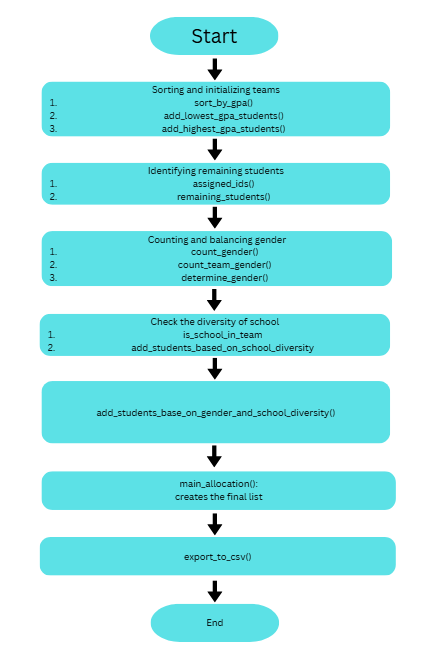

**PATH**

In [1]:
path = "./records.csv"

**UTILIZE IMPORT FUNCTION**

In [2]:
import pprint
import matplotlib as plt
import csv

**OPEN THE FILE AT PATH IN READ MODE**

In [3]:
with open(path, 'r') as file:
  currentlist = list(file)

**SAMPLE RIGHT OF CURRENT LIST**

['Tutorial Group,Student ID,School,Name,Gender,CGPA\n', 'G-1,5002,CCDS,Aarav Singh,Male,4.02\n', 'G-1,3838,EEE,Aarti Nair,Female,4.05\n'....



**PARSE A CSV-LIKE LIST OF LINES INTO A NESTED DICTS**

##### Pseudocode
FUNCTION new_dict(new_list):
    
    REMOVE first element of new_list       
    block_size ← 6
    nested_dict ← {}

    FOR EACH line IN new_list:
      fields ← split line by ','
      outer_key ← fields[0]
      inner_dict ← {}

      FOR j FROM 1 TO length(fields)-1 STEP block_size:
        id_raw ← fields[j]
        inner_key ← zero-pad id_raw to 4 chars
        inner_value ← fields[j+1 : end]        
        TRIM newline from last element of inner_value
        NORMALIZE last element (GPA) to "x.yy"

        inner_dict[inner_key] ← inner_value

      IF outer_key IN nested_dict:
        UPDATE inner_dict INTO nested_dict[outer_key]
      ELSE:
        nested_dict[outer_key] ← inner_dict

    RETURN nested_dict

In [4]:
def new_dict(new_list):
  del new_list[0] #deletes the headers

  block_size = 6 #how many values within the group
  nested_dict = {}

  for i in range(0, len(new_list)):
      block = new_list[i]
      block = block.split(',')
      outer_key = block[0] #outer key


      inner_dict = {} #for formation of the inner dictionary
      for j in range(1, len(block), block_size):
          if len(block[j])<4: #checks the length of the Student ID
              inner_key = ((4-len(block[j]))*"0") + block[j]
          else:
              inner_key = block[j]
          inner_value = block[j+1:] #includes the rest of the block
          inner_value[-1]=inner_value[-1].strip() #removes the "/n" from the last input
          if len(inner_value[-1]) == 1: #standardising the number of digits for the gpa
              inner_value[-1] = (inner_value[-1] + ".00")
          elif len(inner_value[-1]) <4:
              (inner_value[-1]) = (inner_value[-1] + (4-len(inner_value[-1]))*"0")


          inner_dict[inner_key] = inner_value

      if (outer_key in nested_dict): #checks if the key is inside alr
          (nested_dict[outer_key]).update(inner_dict)
      else:
          nested_dict[outer_key] = inner_dict
  return nested_dict

pprint.pprint(new_dict(currentlist))


{'G-1': {'0071': ['SoH', 'Savannah Taylor', 'Female', '4.19'],
         '0075': ['CCDS', 'Sakina Ahmed', 'Female', '4.03'],
         '0162': ['SSS', 'Lila Patel', 'Female', '4.07'],
         '0235': ['CCDS', 'Ming Zhang', 'Male', '4.06'],
         '0288': ['CoB (NBS)', 'Ajay Verma', 'Male', '4.01'],
         '0527': ['EEE', 'Mohit Desai', 'Male', '4.06'],
         '0567': ['CoB (NBS)', 'Isabella Thompson', 'Female', '4.03'],
         '0588': ['MAE', 'Lucas Walker', 'Male', '4.06'],
         '0592': ['MSE', 'Zara Chang', 'Female', '4.11'],
         '0659': ['SSS', 'Maria Ivanovna', 'Female', '4.20'],
         '0809': ['CoB (NBS)', 'Nisha Das', 'Female', '4.26'],
         '0945': ['MAE', 'Han Li', 'Female', '4.10'],
         '1075': ['CoB (NBS)', 'Felix Yip', 'Male', '4.08'],
         '1271': ['SSS', 'Priya Singh', 'Female', '4.17'],
         '1329': ['NIE', 'Nguyen Van Sam', 'Male', '3.85'],
         '1383': ['CoB (NBS)', 'Areeba Khan', 'Female', '4.19'],
         '1417': ['CoE', 'Darre

**SORT 50 STUDENTS BY GPA**

##### Pseudocode
FUNCTION sort_by_gpa(tut_group):

    CREATE empty list sorted_list
    Pairs ← items of tut_group
    Sorted_pairs ← Sort pairs by float(pair.value[-1])
    
    FOR EACH (student_id, student_data) IN sorted_pairs:
        APPEND { student_id : student_data } TO sorted_list
    
    RETURN sorted_list

In [5]:
# Sort 50 students based on GPA
def sort_by_gpa(tut_group):
  sorted_list = []
  sorted_students = sorted(tut_group.items(), key=lambda item: float(item[1][-1]))
  for student_ID, student_data in sorted_students:
    sorted_list.append({student_ID : student_data})
  return sorted_list


**ALLOCATE THE LOWEST 10 GPAs TO THE FIRST INDEX OF 10 SUBLISTS**

##### Pseudocode

FUNCTION add_lowest_gpa_students(tut_group):

    sorted_list ← sort_by_gpa(tut_group)         
    temporary_list ← empty list
    lowest_10 ← first 10 elements of sorted_list
    
    FOR EACH student IN lowest_10:
        APPEND [student] TO temporary_list          
    
    RETURN temporary_list

In [6]:
# Allocate the lowest GPAs to the first index of 10 sublists
def add_lowest_gpa_students(tut_group):
  sorted_list = sort_by_gpa(tut_group)
  temporary_list = []
  lowest_10 = sorted_list[:10]
  for student in lowest_10:
    temporary_list.append([student])
  return temporary_list


**ALLOCATE THE HIGHEST 10 GPAs TO THE SECOND INDEX OF 10 SUBLISTS WHILE ENSURING THE SCHOOL DIVERSITY**

##### Pseudocode
FUNCTION add_highest_gpa_students(tut_group, temporary_list):

    sorted_list ← sort_by_gpa(tut_group)              
    highest_gpa_students ← reverse(sorted_list)      
    FOR i FROM 0 TO length(temporary_list) - 1:
      first_student_id ← key of temporary_list[i][0]
      first_student_school ← tut_group[first_student_id][0]

    FOR EACH student_dict IN highest_gpa_students:
      candidate_id ← key of student_dict
      candidate_school ← student_dict[candidate_id][0]

      IF candidate_school ≠ first_student_school:
        APPEND student_dict TO temporary_list[i]
        REMOVE student_dict FROM highest_gpa_students
        BREAK

    RETURN temporary_list

In [7]:
def add_highest_gpa_students(tut_group, temporary_list):
    sorted_list = sort_by_gpa(tut_group)
    # Get student IDs sorted by GPA in descending order
    highest_gpa_students = sorted_list[::-1]

    for i in range(len(temporary_list)):
        # Get the student ID from the dictionary in the sublist
        first_student_id = list(temporary_list[i][0].keys())[0]
        first_student_school = tut_group[first_student_id][0]
        for student_dict in highest_gpa_students:
            student_id = list(student_dict.keys())[0]
            student_school = student_dict[student_id][0]
            if student_school != first_student_school:
                temporary_list[i].append(student_dict) # Add the student as a dictionary
                highest_gpa_students.remove(student_dict)  # Remove the added student from the list
                break  # Move to the next sublist once a suitable student is found
            else:
                continue
    return temporary_list


**EXTRACT ALL STUDENT IDS FROM THE CURRENT ASSIGNED LIST**

##### Pseudocode
FUNCTION assigned_ids(assigned_list):

    y ← empty list
    FOR EACH row IN assigned_list:
    FOR EACH student_dict IN row:
      key ← first key of student_dict
      APPEND key TO y
    RETURN y

In [8]:
def assigned_ids(assigned_list):
    y = []
    for row in assigned_list:
        for x in row:
            key = list(x)[0]
            y.append(key)
    return y


**IDENTIFY THE DICTIONARY OF REMAINING STUDENTS WHO WERE NOT ASSIGNED**

##### Pseudocode
FUNCTION remaining_students(all_student, assigned):
    
    remaining ← empty dictionary

    FOR EACH student_id IN all_student:
      IF student_id NOT IN assigned:
        remaining[student_id] ← all_student[student_id]

    RETURN remaining

In [9]:
def remaining_students(all_student, assigned):
    remaining = {}

    for student_id in all_student:
        if student_id not in assigned:
            remaining[student_id] = all_student[student_id]

    return remaining


**COUNT THE NUMBER OF MALE AND FEMALE STUDENTS WHO WERE NOT ASSIGNED**

##### Pseudocode
FUNCTION count_gender(data):

    m ← 0
    f ← 0

    FOR EACH key IN data:
      IF data[key][2] == "Male":
        m ← m + 1
      ELSE IF data[key][2] == "Female":
        f ← f + 1

    RETURN (m, f)

In [10]:
#General use for counting gender, provided data is a dict
def count_gender(data):
    m = 0
    f = 0
    for i in data:
        if data[i][2] == "Male":
            m += 1
        elif data[i][2] == "Female":
            f += 1
    return m,f


**COUNT THE NUMBER OF MALE AND FEMALE STUDENTS WHO WERE ASSIGEND**

##### Pseudocode
FUNCTION count_team_gender(assign_team):
  
    assign_m ← 0
    assign_f ← 0

    FOR EACH row IN assign_team:
      (m, f) ← count_gender(row)
      IF m == 1:
        assign_m ← assign_m + 1
      ELSE IF f == 1:
        assign_f ← assign_f + 1

    RETURN (assign_m, assign_f)

In [11]:
#Extra step since the dict for assign team is inside a list
def count_team_gender(assign_team):
    assign_m = 0
    assign_f = 0
    for row in assign_team:
        m,f = count_gender(row)
        if m == 1:
            assign_m += 1
        elif f == 1:
            assign_f += 1
    return assign_m,assign_f


**DETERMINE THE GENDER**

##### Pseudocode
FUNCTION determine_gender(assign_m, assign_f, remaining_m, remaining_f):

    IF assign_m == 2 AND assign_f == 0:
      RETURN "Female"

    IF assign_m == 0 AND assign_f == 2:
      RETURN "Male"

    IF assign_m == 1 AND assign_f == 1:
      IF remaining_m > remaining_f:
        RETURN "Male"
      IF remaining_f > remaining_m:
        RETURN "Female"
      RETURN None

    IF assign_m == 2 AND assign_f == 1:
      RETURN "Female"

    IF assign_m == 1 AND assign_f == 2:
      RETURN "Male"

    RETURN None

In [12]:
#Condition to determine which student to add based on gender
def determine_gender(assign_m, assign_f, remaining_m, remaining_f):

    if assign_m == 2 and assign_f == 0:
        return "Female"
    if assign_m == 0 and assign_f == 2:
        return "Male"

    if assign_m == 1 and assign_f == 1:
        if remaining_m > remaining_f:
            return "Male"
        if remaining_f > remaining_m:
            return "Female"
        return None

    if assign_m == 2 and assign_f == 1:
        return "Female"
    if assign_m == 1 and assign_f == 2:
        return "Male"

    return None


**CHECK THE SCHOOL DUPLICATE**

##### Pseudocode
FUNCTION is_school_in_team(student_data, sub_group):
  
    student_school ← student_data[0]

    FOR EACH team_member IN sub_group:
      member_school ← first value of team_member → [0]  // extract school
      IF student_school == member_school:
        RETURN True

    RETURN False

In [13]:
# Function to check if a student's school is already in a given team##################################
def is_school_in_team(student_data, sub_group):
    student_school = student_data[0]
    for team_member in sub_group:
        team_member_school = list(team_member.values())[0][0]
        if student_school == team_member_school:
          return True
    return False


**FILTER STUDENTS BASED ON THE SCHOOL DIVERSITY**

##### Pseudocode
FUNCTION add_student_based_on_school_diversity(teams, remaining_students_copy):
  
    FOR EACH team IN teams:
      IF length(team) >= 5:
        CONTINUE

      FOR EACH (student_id, student_data) IN remaining_students_copy:
        IF NOT is_school_in_team(student_data, team):
          APPEND {student_id: student_data} TO team
          REMOVE student_id FROM remaining_students_copy
          BREAK

In [14]:
# Function to just add 5th member based purely on school diversity ##################################
def add_student_based_on_school_diversity(teams, remaining_students_copy):

    for team in teams:
        if len(team) >= 5:
            continue  # Team already full, don't add anymore students

        student_added = False
        for student_id, student_data in remaining_students_copy.items():
            if not is_school_in_team(student_data, team): # New school => diverse => can add!
                team.append({student_id: remaining_students_copy[student_id]}) # Add the student to team
                del remaining_students_copy[student_id] # Remove the added student from the remaining pool
                student_added = True
                break  # Move to the next team after adding a student



**ALLOCATE STUDENTS BASED ON THE SCHOOL DIVERSITY AND GENDER DIVERSITY**

##### Pseudocode
FUNCTION add_student_base_on_gender_and_school_diversity(temporary_list, remaining_student_data):

    remaining ← copy of remaining_student_data

    FOR EACH sub_group IN temporary_list:
      IF size(sub_group) >= 4:
        CONTINUE

      (assign_m, assign_f) ← count_team_gender(sub_group)
      (rem_m, rem_f) ← count_gender(remaining)
      need ← determine_gender(assign_m, assign_f, rem_m, rem_f)

      filtered ← { (id, s) FROM remaining WHERE (need IS None) OR (s[2] == need) }

      added ← False
      FOR EACH (id, s) IN filtered:
        IF NOT is_school_in_team(s, sub_group):
          APPEND {id: s} TO team
          DELETE id FROM remaining
          added ← True
          BREAK

      IF NOT added:
        FOR EACH (id, s) IN remaining:
          IF NOT is_school_in_team(s, sub_group):
            APPEND {id: s} TO team
            DELETE id FROM remaining
            BREAK

    IF (ANY team has size < 4) AND (remaining not empty):
    CALL add_student_base_on_gender_and_school_diversity(teams, remaining)

    CALL add_student_based_on_school_diversity(teams, remaining)

    RETURN teams

In [15]:
#Add student based on gender and school diversity##################################
def add_student_base_on_gender_and_school_diversity(temporary_list, remaining_student_data): # Renamed parameter
    # Create a copy of the remaining students dictionary to modify during iteration
    remaining_students_copy = remaining_student_data.copy() # Use the renamed parameter


    for sub_group in temporary_list:
        if len(sub_group) >= 4:  # Skip if the team is already full
            continue

        # Determine the needed gender for the current team
        assign_m, assign_f = count_team_gender(sub_group)
        remaining_m, remaining_f = count_gender(remaining_students_copy)
        needed_gender = determine_gender(assign_m, assign_f, remaining_m, remaining_f)

        # Filter remaining students by needed gender
        filtered_students_by_gender = {
            student_id: student_data for student_id, student_data in remaining_students_copy.items()
            if needed_gender is None or student_data[2] == needed_gender
        }

        # Iterate through filtered students and add the first one that satisfies the school diversity criteria
        student_added = False
        for student_id, student_data in filtered_students_by_gender.items():
            if not is_school_in_team(student_data, sub_group):
                sub_group.append({student_id: student_data})
                del remaining_students_copy[student_id]  # Remove the added student from the remaining pool
                student_added = True
                break  # Move to the next team after adding a student
        # If no student was added to the current team based on gender and school diversity,
        # try adding any remaining student as long as it satisfies school diversity
        if not student_added:
            for student_id, student_data in remaining_students_copy.items():
                if not is_school_in_team(student_data, sub_group):
                    sub_group.append({student_id: student_data})
                    del remaining_students_copy[student_id]
                    student_added = True
                    break


    # Recursively call the function until all teams are full or no more students can be added
    if any(len(team) < 4 for team in temporary_list) and len(remaining_students_copy) > 0:
        add_student_base_on_gender_and_school_diversity(temporary_list, remaining_students_copy)

    # Add 5th member based purely on school diversity ##################################
    add_student_based_on_school_diversity(temporary_list, remaining_students_copy)

    return temporary_list


**MAIN FUNCTION**

##### Pseudocode

FUNCTION main_allocation(data):
  
    teams ← add_lowest_gpa_students(data)

    teams ← add_highest_gpa_students(data, teams)

    assigned ← assigned_ids(teams)
    remaining ← remaining_students(data, assigned)

    teams ← add_student_based_on_gender_and_school_diversity(teams, remaining)

    team_dict ← empty dictionary
    i ← 1
    
    FOR EACH team IN teams:
      team_dict[i] ← team
      i ← i + 1

    RETURN team_dict

In [16]:
def main_allocation(data):
    # Add first student based on GPA
    teams = add_lowest_gpa_students(data)

    # Add second student based on highest GPA and school diversity
    teams = add_highest_gpa_students(data, teams)

    # Get the remaining students after adding the first two
    assigned = assigned_ids(teams)
    remaining_students_data = remaining_students(data, assigned)

    # Add students based on gender and school diversity
    teams = add_student_base_on_gender_and_school_diversity(teams, remaining_students_data)

    # Format the output as a dictionary with numerical keys
    team_dict = {}
    for i, team in enumerate(teams, start=1):
        team_dict[i] = team

    return team_dict

all_allocated_teams = {group_name: main_allocation(group_data) for group_name, group_data in (new_dict(currentlist)).items()}
pprint.pprint(all_allocated_teams)

{'G-1': {1: [{'1329': ['NIE', 'Nguyen Van Sam', 'Male', '3.85']},
             {'3861': ['ASE', 'Layla Torres', 'Female', '4.52']},
             {'3838': ['EEE', 'Aarti Nair', 'Female', '4.05']},
             {'0588': ['MAE', 'Lucas Walker', 'Male', '4.06']},
             {'0567': ['CoB (NBS)', 'Isabella Thompson', 'Female', '4.03']}],
         2: [{'3148': ['EEE', 'Gabriel Young', 'Male', '3.88']},
             {'2069': ['SSS', 'Kathy Lau', 'Female', '4.48']},
             {'4479': ['CCDS', 'Amelia Kim', 'Female', '4.11']},
             {'2818': ['CoB (NBS)', 'Oliver Tan', 'Male', '4.09']},
             {'5119': ['ADM', 'Nhung Vu', 'Female', '4.04']}],
         3: [{'2417': ['SSS', 'Truong Minh Chau', 'Female', '3.88']},
             {'0809': ['CoB (NBS)', 'Nisha Das', 'Female', '4.26']},
             {'3989': ['WKW SCI', 'Anthony Liu', 'Male', '4.15']},
             {'4576': ['EEE', 'Jie Zhang', 'Male', '4.03']},
             {'2650': ['SoH', 'Nurul Shafika', 'Female', '4.09']}],
   

**EXPORTING THE DATA OUT**

##### Pseudocode
FUNCTION export_to_csv(data):
  
    header ← ['Tutorial Group','Student ID','School','Name','Gender','CGPA','Team Assigned']

    OPEN "Student_groups.csv" for writing as csvfile
    WRITE header to csvfile

    FOR EACH (group_key, group_value) IN data:
      FOR EACH (team_key, team_list) IN group_value:
        FOR EACH student_dict IN team_list:
          (student_id, details) ← the single (key, value) in student_dict
          row ← [group_key, student_id, details[0], details[1], details[2], details[3], team_key]
          WRITE row to csvfile

    CLOSE csvfile

In [17]:
def export_to_csv(data):
    header = ['Tutorial Group','Student ID', 'School', 'Name', 'Gender', 'CGPA','Team Assigned'] #the headers of the csv file
    data_rows = [header]
    for group_key, group_value in data.items(): #extracting the information from the 3 nested dictionaries (tutorial group)
        for list_key, list_value in group_value.items(): #the groups of 5 in the tut group
            for student_dict in list_value: #the student id in the group
                for student_id, details in student_dict.items(): #the info about the students
                    row = [
                        group_key,
                        student_id,
                        details[0],
                        details[1],
                        details[2],
                        details[3],
                        list_key
                    ]
                    data_rows.append(row) #forms the list of lists
    filename = "FCEB_Team2_NguyenThanhDuy.csv"
    with open(filename, 'w', newline='') as csvfile:
      csv_writer = csv.writer(csvfile)
      csv_writer.writerows(data_rows)
export_to_csv(all_allocated_teams)


**VISUALIZATION OF THE RESULTS**

{'2M-3F': 766, '3M-2F': 404, '1M-4F': 28, '4M-1F': 2}
{'5 schools': 1200}
{'1x4.5-5.0 + 4x3.5–4.5': 76, '5x3.5–4.5': 1124}


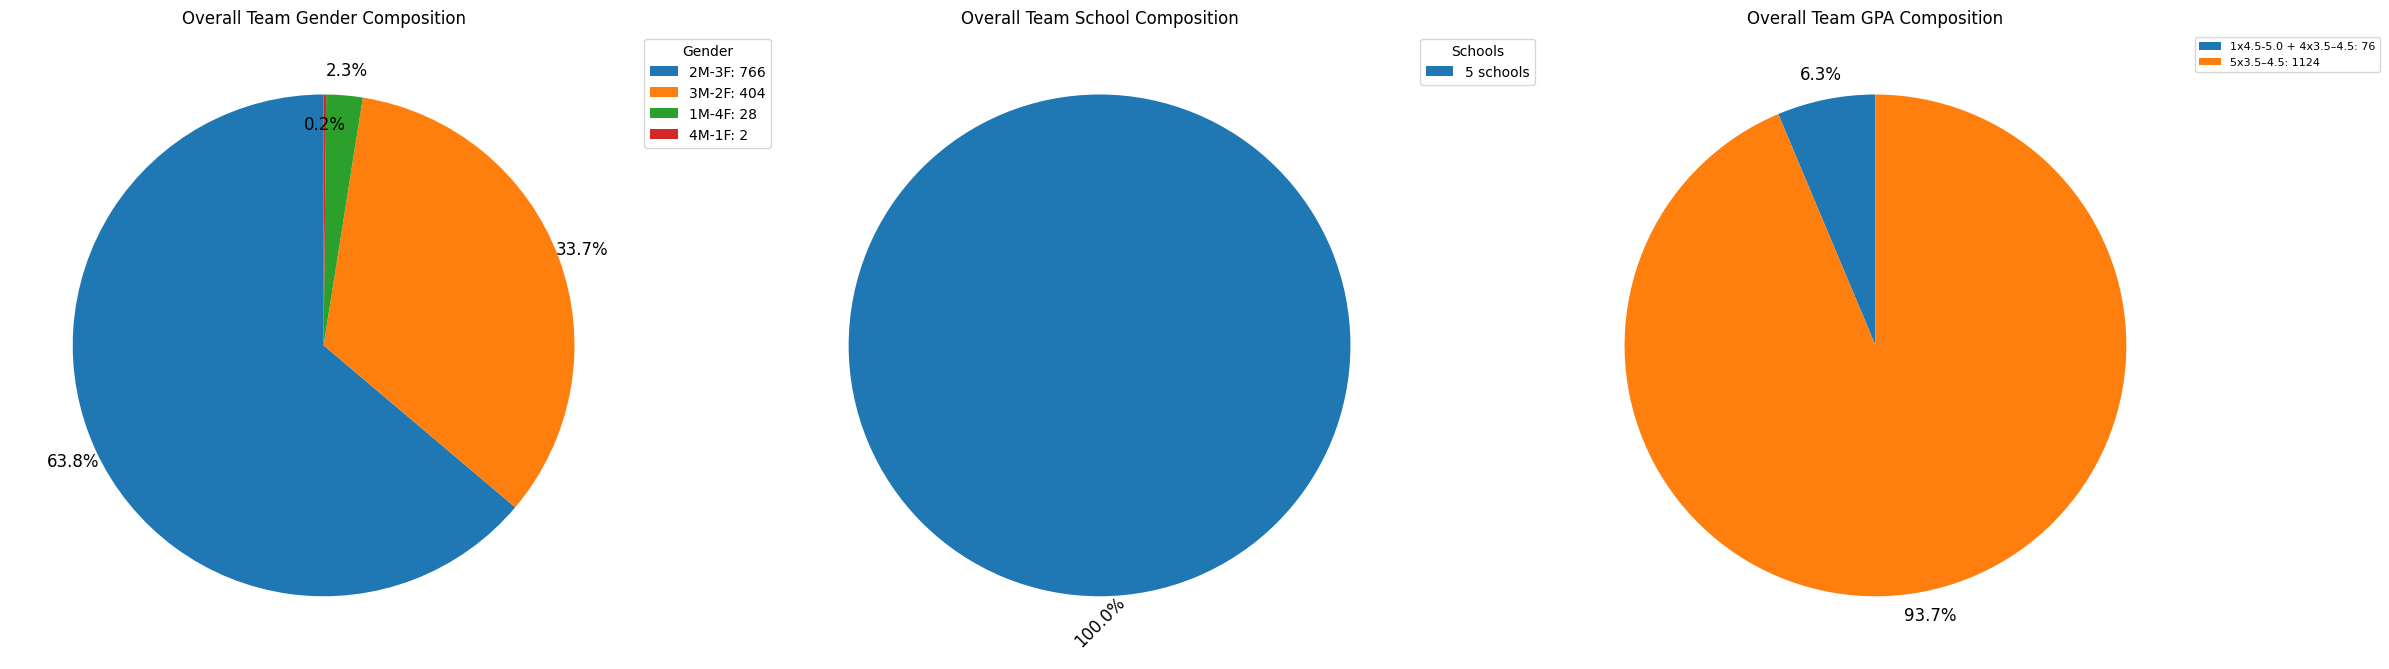

In [18]:
import matplotlib.pyplot as plt

def plot_overall_team_gender_composition(data, ax=None):
    counts = {}
    for tg, teams in data.items():
        for team_id, members in teams.items():
            m = f = 0
            for stud in members:
                sid, vals = next(iter(stud.items()))
                g = vals[2].lower()
                if g == "male":   m += 1
                elif g == "female": f += 1
            label = f"{m}M-{f}F"
            counts[label] = counts.get(label, 0) + 1

    labels_lst = list(counts.keys())
    sizes  = list(counts.values())
    labels = []

    for i in range(len(labels_lst)):
      labels.append(f"{labels_lst[i]}: {sizes[i]}")

    wedges, text , autotexts = axes2[0].pie(sizes, labels=None, autopct='%1.1f%%',
                          startangle=90, pctdistance = 1.1)
    axes2[0].set_title("Overall Team Gender Composition")
    axes2[0].legend(wedges, labels, title="Gender", loc="upper left", bbox_to_anchor=(1, 0, 0.5, 1))


    min_size = min(sizes)
    for i, text in enumerate(autotexts):
        text.set_color('black')
        text.set_fontsize(12)
        if sizes[i] == min_size:
            text.set_position((text.get_position()[0]*1.2, text.get_position()[1]*0.8))


    print(counts)


def plot_overall_team_school_composition(data, ax=None):
    counts = {}
    for tg, teams in data.items():
        for team_id, members in teams.items():
            schools = set()
            for stud in members:
                sid, vals = next(iter(stud.items()))
                schools.add(vals[0].lower())
            label = f"{len(schools)} schools"
            counts[label] = counts.get(label, 0) + 1

    labels = list(counts.keys())
    sizes  = list(counts.values())


    wedges, text , autotexts = axes2[1].pie(sizes, labels=None, autopct='%1.1f%%',
                          startangle=90, pctdistance=1.1,
                          textprops={'rotation':45})
    axes2[1].set_title("Overall Team School Composition")
    axes2[1].legend(wedges, labels, title="Schools", loc="upper left", bbox_to_anchor=(1, 0, 0.5, 1))


    for text in autotexts:
        text.set_color('black')
        text.set_fontsize(12)


    print(counts)


def plot_overall_team_gpa_composition(data, ax=None):
    def gpa_check(g):
      fg = float(g)
      if  fg <= 2.0: return "0–2.0"
      elif fg <= 3.0: return "2.1–2.5"
      elif fg <= 3.5: return "2.5–3.5"
      elif fg <= 4.5: return "3.5–4.5"
      else: return "4.5-5.0"

    counts = {}

    for tg, teams in data.items():
        for team_id, members in teams.items():
            gpa_lst = []
            bins = {"0–2.0":0, "2.1–2.5":0, "2.5–3.5":0,
                    "3.5–4.5":0, "4.5-5.0":0}
            for stud in members:
                sid, vals = next(iter(stud.items()))
                bins[gpa_check(vals[3])] += 1
                gpa_lst.append(float(vals[3]))
            parts = [f"{c}x{b}" for b, c in bins.items() if c]
            parts.sort()
            label = " + ".join(parts) or "Empty"
            counts[label] = counts.get(label, 0) + 1


    labels_lst = list(counts.keys())
    sizes  = list(counts.values())
    labels = []

    for i in range(len(labels_lst)):
      labels.append(f"{labels_lst[i]}: {sizes[i]}")


    wedges, text, autotexts = axes2[2].pie(sizes, labels=None, autopct='%1.1f%%',
                          startangle=90, textprops={'fontsize':9}, pctdistance=1.1)
    axes2[2].set_title("Overall Team GPA Composition")
    axes2[2].legend(wedges, labels, loc="upper left", fontsize=8, bbox_to_anchor=(1, 0, 0.5, 1))


    for text in autotexts:
        text.set_color('black')
        text.set_fontsize(12)


    print(counts)



fig, axes2 = plt.subplots(1, 3, figsize=(24, 8))

plot_overall_team_gender_composition(all_allocated_teams, ax=axes2[0])
plot_overall_team_school_composition(all_allocated_teams, ax=axes2[1])
plot_overall_team_gpa_composition(all_allocated_teams, axes2[2])

plt.tight_layout()
plt.show()

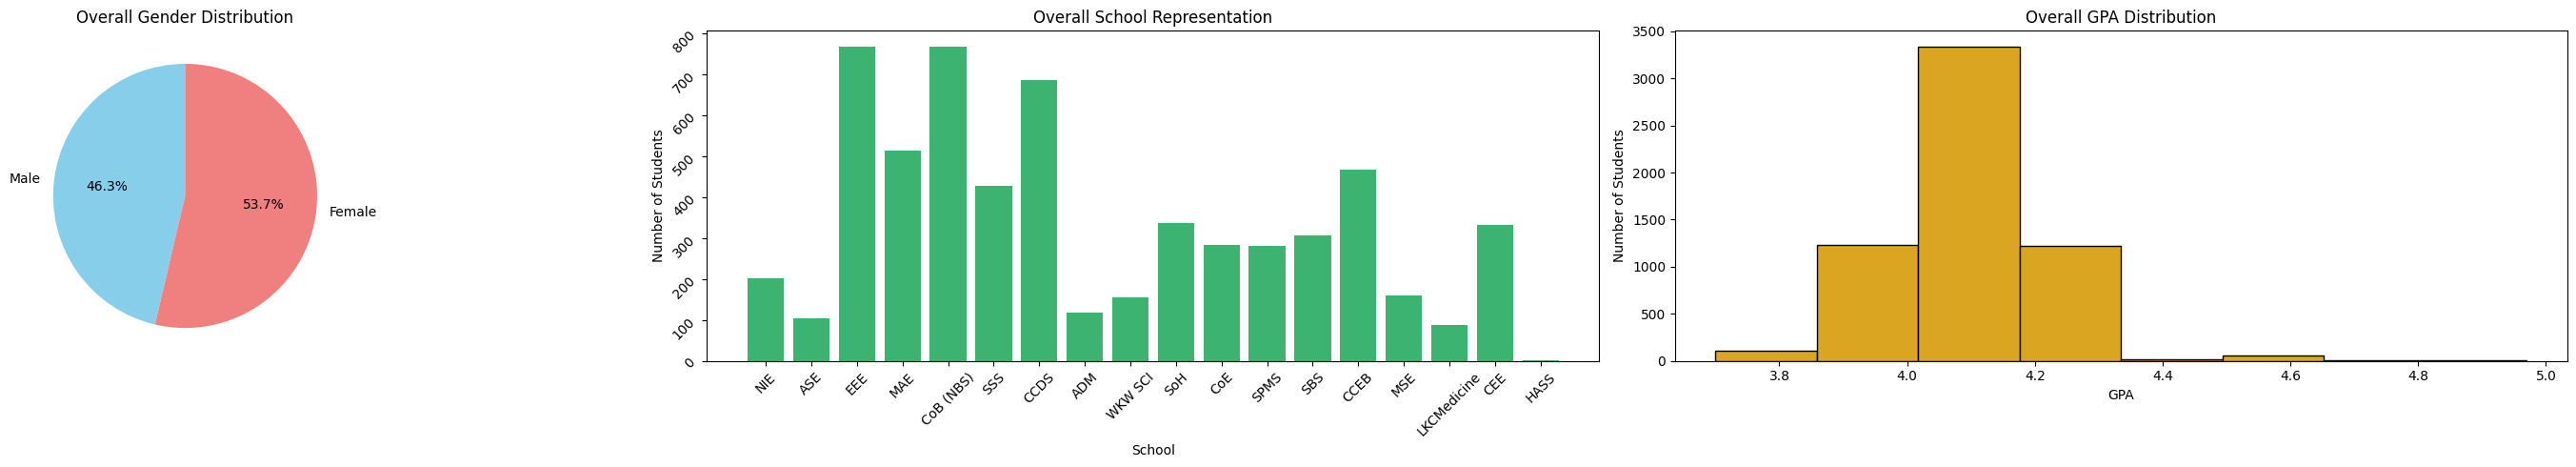

In [19]:
import matplotlib.pyplot as plt

#extracting a list of students for convenience
def students_list(data):
    stud_list = []
    for grp in data.values():
        for team in grp.values():
            for students in team:
                for id, details in students.items():
                    stud_list.append(details)
    return stud_list

fig, axes = plt.subplots(1, 3, figsize=(30, 5))
def gender_dist_overall(data):
    students = students_list(data)
    m = 0
    f = 0
    for i in students:
      if i[2].lower() == "male":
        m+=1
      else:
        f+=1


    axes[0].pie([m, f], labels=['Male', 'Female'],
            autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=90)
    axes[0].set_title("Overall Gender Distribution")



def school_dist_overall(data):
    students = students_list(data)
    schools = {}
    for i in students:
        schools[i[0]] = schools.get(i[0], 0) + 1

    axes[1].bar(schools.keys(), schools.values(), color='mediumseagreen')
    axes[1].set_title("Overall School Representation")
    axes[1].set_xlabel("School")
    axes[1].set_ylabel("Number of Students")
    axes[1].tick_params(rotation=45)



def gpa_dist_overall(data):
    students = students_list(data)
    gpas = [float(s[3]) for s in students]

    axes[2].hist(gpas, bins=8, color='goldenrod', edgecolor='black')
    axes[2].set_title("Overall GPA Distribution")
    axes[2].set_xlabel("GPA")
    axes[2].set_ylabel("Number of Students")

gender_dist_overall(all_allocated_teams)
school_dist_overall(all_allocated_teams)
gpa_dist_overall(all_allocated_teams)
plt.tight_layout()
plt.show()



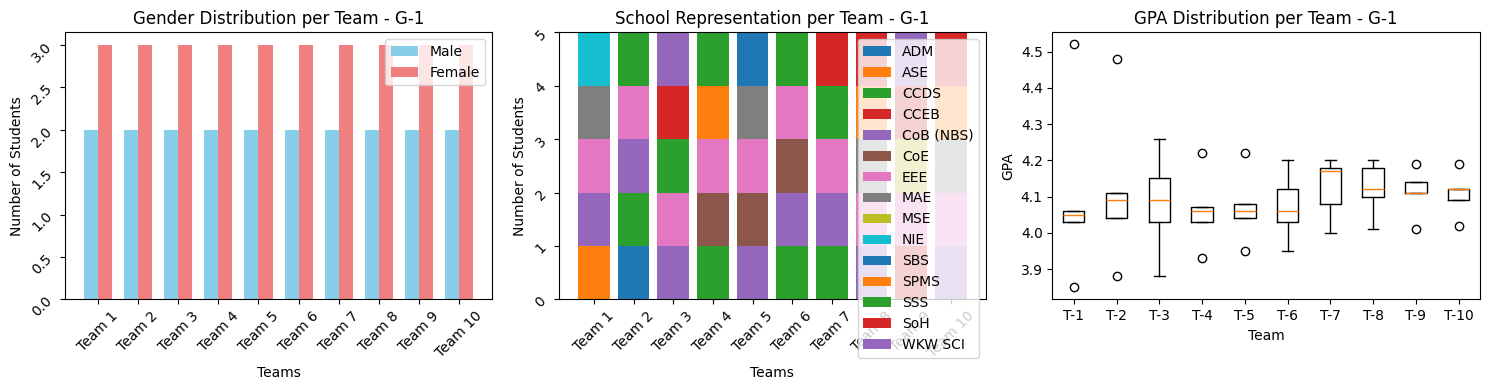

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def gender_dist_perteam(data, tutorial_group_name):
    group_data = data[tutorial_group_name]
    team_ids = sorted(group_data.keys())

    male_counts, female_counts = [], []
    for team_id in team_ids:
        m = f = 0
        for student_dict in group_data[team_id]:
            for sid, vals in student_dict.items():
                if vals[2].lower() == "male": m += 1
                else: f += 1
        male_counts.append(m)
        female_counts.append(f)

    x = range(len(team_ids))
    bar_width = 0.35

    axes[0].bar([i - bar_width/2 for i in x], male_counts, width=bar_width, label='Male', color='skyblue')
    axes[0].bar([i + bar_width/2 for i in x], female_counts, width=bar_width, label='Female', color='lightcoral')
    axes[0].set_xticks(x, [f"Team {i}" for i in team_ids])
    axes[0].set_xlabel("Teams")
    axes[0].set_ylabel("Number of Students")
    axes[0].set_title(f"Gender Distribution per Team - {tutorial_group_name}")
    axes[0].legend(loc="upper right")
    axes[0].tick_params(rotation=45)

def school_dist_perteam(data, tutorial_group_name):
    group_data = data[tutorial_group_name]
    team_ids = sorted(group_data.keys())
    all_schools = sorted({vals[0] for team in group_data.values() for s in team for sid, vals in s.items()})
    school_counts = {school: [] for school in all_schools}

    for team_id in team_ids:
        counts = {school: 0 for school in all_schools}
        for s in group_data[team_id]:
            for sid, vals in s.items():
                counts[vals[0]] += 1
        for school in all_schools:
            school_counts[school].append(counts[school])

    bottom = [0]*len(team_ids)
    for school in all_schools:
        axes[1].bar(team_ids, school_counts[school], bottom=bottom, label=school)
        bottom = [sum(x) for x in zip(bottom, school_counts[school])]

    axes[1].set_xticks(team_ids, [f"Team {i}" for i in team_ids])
    axes[1].set_xlabel("Teams")
    axes[1].set_ylabel("Number of Students")
    axes[1].set_title(f"School Representation per Team - {tutorial_group_name}")
    axes[1].legend(loc = "upper right")
    axes[1].tick_params(rotation=45)

def gpa_dist_perteam(data, tutorial_group_name):
    group_data = data[tutorial_group_name]
    team_ids = sorted(group_data.keys())
    gpa_lists = []

    for team_id in team_ids:
        gpas = []
        for s in group_data[team_id]:
            for sid, vals in s.items():
                gpas.append(float(vals[3]))
        gpa_lists.append(gpas)

    axes[2].boxplot(gpa_lists, tick_labels=[f"T-{i}" for i in team_ids])
    axes[2].set_title(f"GPA Distribution per Team - {tutorial_group_name}")
    axes[2].set_xlabel("Team")
    axes[2].set_ylabel("GPA")
    axes[1].tick_params(rotation=45)


gender_dist_perteam(all_allocated_teams, "G-1")
school_dist_perteam(all_allocated_teams, "G-1")
gpa_dist_perteam(all_allocated_teams, "G-1")

plt.tight_layout()
plt.show()


### Conclusion

#### Time complexity:

The worst-case time complexity of the entire code would be O(n^2) due to the nested iterations over groups and students in functions like add_student_based_on_school_diversity and add_student_base_on_gender_and
_school_diversity.


#### Effectiveness:

Our code is organised into functions, which helps to make it more readable. Each function has its specific purpose, making it easily understandable. The use of functions also enables isolated testing of the individual functions, which helps to make debugging the code easier. Therefore, our code, by being separated into a modular design, enhances readability and the ease of debugging it.

Our algorithm uses a greedy algorithm and sorts students into groups based on school affiliation, gender and GPA instead of using a random allocation method and checking whether it suits the criteria. This makes our algorithm more efficient than random sorting, as it reduces the need for repeated checks and adjustments that come with random allocation. It also minimises the need to iterate and generate a new grouping which is needed for random allocation to fulfill the requirements of the criteria.


#### Limitations:

Our code uses fixed values for our group sizes and the number of groups based on the CSV file provided by the school which reduces our flexibility to adapt and change based on the other files or group sizes that could be provided.

For example, if the group sizes were to be changed to 10, our code would have to be altered significantly to adapt to the new requirements. Depending on the datasets used, our algorithm’s efficiency might be decreased as currently our dataset used is only 6000 students.

Furthermore, our code does not have checks to handle errors such as empty input, invalid data types etc as the CSV file provided by the school is fixed with no such errors. Therefore, our code does not include error handling.

### APPENDIX B: USE OF AI TOOL(S) IN PROJECT WORK

Each team member should indicate either A or B.
A. I affirm that my contribution(s) to the lab work is my own, produced without help from any Al tool(s)
B. I affirm that my contribution(s) to the lab work has been produced with the help from Al tool(s)

| Full Name                  |   Date      | A or B      |
|----------------------------|-------------|-------------|
| NGUYEN THANH DUY           | 10/11/2025  |     A       |
| AGALYAA GOPALAKRISHNAN     | 10/11/2025  |     A       |
| LUM YU PEI                 | 10/11/2025  |     A       |
| SARIN LAKSHYA ANUJ         | 10/11/2025  |     A       |
| THANG JING MIN             | 10/11/2025  |     A       |


By including this information in your jupyter notebook, you declare that the above affirmation made is true and that you have read and understood NTU's policy on the use of Al tools.
If any team member answered B, the team member(s) must indicate and replicate the table below for every instance Al tool(s) is used.
